# Initialization strategies — a controlled comparison (DLCC synthetic tc01–tc15)

This notebook closes the gap flagged in the thesis (Section 3.1, *Initialization
Strategies along the Class Hierarchy*): **a dedicated quantitative comparison of
the four class-hierarchy initialization strategies, on the same TC set and under
the same budget.**

The classic protograph transfer pretrains skip-gram on a protograph (P1/P2/P3),
then seeds every typed instance from the pretrained *codes* of its classes. The
four strategies differ only in **which** class vectors seed an instance:

| strategy | rule |
|---|---|
| `most_specific` | MASCHInE rule: mean of the codes of the instance's **most specific** classes; instances whose classes are all out-of-vocabulary stay **random**. |
| `all_init` | like `most_specific`, but climb `rdfs:subClassOf` **upward** until a covered ancestor is found — a coverage remedy. |
| `average_hier` | mean over the instance's classes **and all transitive superclasses** (uniform blend). |
| `weight_hierarchy` | like `average_hier`, but ancestors at hop distance $d$ are down-weighted by $\lambda^{d}$ (default $\lambda=0.5$). |

### Experimental design — what is held constant

Everything except the strategy is fixed, so the comparison is *clean*:

* **Same TC set** — the fifteen synthetic DLCC test cases (`tc01`–`tc15`), matching
  the thesis main results table.
* **Same budget** — `dim=200`, 100 instance walks/entity, 200 protograph
  walks/entity, depth 3, 5 pretrain + 5 finetune epochs, codes normalized to
  `TARGET_NORM=8`, protected finetune LR `0.0025 → 0.0001`, `syn1neg` mirror,
  `seed=42`. Identical for every strategy.
* **Three protographs** — the strategies are remedies for the *leaf-class coverage
  gap*, which is widest under **P1** (domain/range classes only), narrower under
  **P2** (+ direct subclasses), and closed by **P3** (+ full `subClassOf`
  hierarchy), so we report all three.
* **`vanilla`** (from-scratch RDF2Vec) is included as a reference anchor.

The only moving part is *which* class vectors seed an instance — exactly the
question the thesis paragraph asks. All heavy lifting lives in
`scripts/_init_strategies.py` (which builds on `scripts/_synthetic_compare.py`);
walk corpora are reused from `notebooks/synthetic_compare/`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path("..").resolve()
SCRIPTS = ROOT / "scripts"
if str(SCRIPTS) not in sys.path:
    sys.path.insert(0, str(SCRIPTS))

from _init_strategies import (  # noqa: E402
    ALL_TCS, CFG, OUT_ROOT, PROTOGRAPHS, STRATEGIES,
    load_results, run_all, tc_paths,
)

# Sanity-check that every TC has its data on disk.
missing = [tc for tc in ALL_TCS for k, p in tc_paths(tc).items()
           if k != "walk_dir" and not Path(p).is_file()]
assert not missing, f"missing data files: {missing}"

print(f"Output root : {OUT_ROOT}")
print(f"TC set      : {', '.join(ALL_TCS)}")
print(f"Strategies  : {', '.join(STRATEGIES)}")
print(f"Protographs : {', '.join(PROTOGRAPHS)}")
print("Budget      :", {k: CFG[k] for k in
      ('dim', 'walks_per_entity', 'depth', 'epochs', 'pretrain_epochs',
       'finetune_alpha', 'target_norm', 'ancestor_decay', 'seed')})

Output root : /home/bnukhkadiev/Knowledge-Graphs/notebooks/init_strategies
TC set      : tc01, tc02, tc03, tc04, tc05, tc06, tc07, tc08, tc09, tc10, tc11, tc12, tc13, tc14, tc15
Strategies  : most_specific, all_init, average_hier, weight_hierarchy
Protographs : p1, p2, p3
Budget      : {'dim': 200, 'walks_per_entity': 100, 'depth': 3, 'epochs': 5, 'pretrain_epochs': 5, 'finetune_alpha': 0.0025, 'target_norm': 8.0, 'ancestor_decay': 0.5, 'seed': 42}


## Run (or load) the comparison

`run_all()` trains, per test case, `vanilla` plus the **4 strategies × {P1, P2, P3}**
= 13 models and caches the result rows to `notebooks/init_strategies/results.json`.
It is incremental: re-running only fills in missing test cases. Delete the JSON
to force a full re-run (≈ 60 min on this machine).

In [2]:
results = run_all()  # cached after the first run
n_variants = {tc: len(rows) for tc, rows in results.items()}
print(f"{len(results)} test cases, variants each:",
      sorted(set(n_variants.values())))

tc01: cached (13 variants)


tc02: cached (13 variants)


tc03: cached (13 variants)


tc04: cached (13 variants)


tc05: cached (13 variants)


...

tc12: cached (13 variants)


tc13: cached (13 variants)


tc14: cached (13 variants)


tc15: cached (13 variants)


16 test cases, variants each: [9, 13]


## Build the data frames

For every result row we recover:

* **`final_acc`** — LogReg test accuracy after the 5th finetune epoch;
* **`init_acc`** — accuracy at epoch 0 (right after initialization, before any
  finetuning) — how much schema signal the *initialization alone* injects;
* **`coverage`** — fraction of typed instances that received a class-based init
  rather than falling back to random (`class_init / (class_init + random)`).

In [3]:
def split_variant(v: str):
    if v == "vanilla":
        return None, "vanilla"
    proto, strat = v.split("_", 1)
    return proto, strat

def coverage(stats):
    if not stats:
        return np.nan
    covered = stats["class_init"] + stats["stage1_copied"] * 0  # instances only
    denom = stats["class_init"] + stats["random"]
    return covered / denom if denom else np.nan

# Aggregate over ALL_TCS (the thesis benchmark tc01--tc15) only; results.json may
# also hold extra TCs (e.g. tc16) that are not part of the benchmark.
recs = []
for tc in ALL_TCS:
    for r in results.get(tc, []):
        proto, strat = split_variant(r["variant"])
        recs.append(dict(
            tc=tc, proto=proto, strategy=strat, variant=r["variant"],
            init_acc=r["accs"][0], final_acc=r["final_acc"],
            best_acc=max(r["accs"]), coverage=coverage(r["init_stats"]),
        ))
df = pd.DataFrame(recs).sort_values(["tc", "variant"]).reset_index(drop=True)
df.head(10)

,tc,proto,strategy,variant,init_acc,final_acc,best_acc,coverage
0,tc01,p1,all_init,p1_all_init,0.4975,0.4950,0.4975,1.000000
1,tc01,p1,average_hier,p1_average_hier,0.4775,0.4775,0.4775,1.000000
2,tc01,p1,most_specific,p1_most_specific,0.5025,0.9225,0.9225,0.555689
3,tc01,p1,weight_hierarchy,p1_weight_hierarchy,0.4775,0.4775,0.4775,1.000000
4,tc01,p2,all_init,p2_all_init,0.5275,0.9050,0.9050,1.000000
5,tc01,p2,average_hier,p2_average_hier,0.5100,0.9050,0.9050,1.000000
6,tc01,p2,most_specific,p2_most_specific,0.5250,0.9100,0.9150,0.854436
7,tc01,p2,weight_hierarchy,p2_weight_hierarchy,0.5150,0.9250,0.9250,1.000000
8,tc01,p3,all_init,p3_all_init,0.5225,0.9225,0.9225,1.000000
9,tc01,p3,average_hier,p3_average_hier,0.5350,0.5350,0.5350,1.000000


## Final accuracy per strategy

One pivot per protograph: rows are test cases, columns the four strategies, the
`vanilla` anchor is shown alongside, and the bottom row is the mean over all 15
test cases.

In [4]:
vanilla_final = df[df.strategy == "vanilla"].set_index("tc")["final_acc"]

def acc_pivot(proto: str, value="final_acc"):
    sub = df[df.proto == proto].pivot(index="tc", columns="strategy", values=value)
    sub = sub[STRATEGIES]
    sub.insert(0, "vanilla", vanilla_final)
    sub = sub.reindex(ALL_TCS)
    sub.loc["mean"] = sub.mean()
    return sub.round(4)

for proto in PROTOGRAPHS:
    print(f"\n=== {proto.upper()} — final LogReg test accuracy (epoch 5) ===")
    display(acc_pivot(proto))


=== P1 — final LogReg test accuracy (epoch 5) ===


strategy,vanilla,most_specific,all_init,average_hier,weight_hierarchy
tc,,,,,
tc01,0.9625,0.9225,0.4950,0.4775,0.4775
tc02,0.8450,0.8575,0.6850,0.4450,0.4425
tc03,0.9450,0.9325,0.4850,0.4925,0.4925
tc04,1.0000,0.9925,0.9950,0.7500,0.7950
tc05,0.8575,0.9425,0.9275,0.9350,0.9375
tc06,0.9850,0.8275,0.4875,0.4325,0.4875
tc07,0.5825,0.5350,0.4850,0.4825,0.4825
tc08,0.5950,0.5300,0.5050,0.4950,0.5000
tc09,0.6575,0.6325,0.4500,0.4600,0.4700



=== P2 — final LogReg test accuracy (epoch 5) ===


strategy,vanilla,most_specific,all_init,average_hier,weight_hierarchy
tc,,,,,
tc01,0.9625,0.9100,0.9050,0.9050,0.9250
tc02,0.8450,0.8575,0.8325,0.4850,0.8775
tc03,0.9450,0.9250,0.9300,0.5000,0.7775
tc04,1.0000,0.9950,0.9950,0.9875,1.0000
tc05,0.8575,0.9250,0.9375,0.9325,0.9350
tc06,0.9850,0.9775,0.9800,0.7125,0.9750
tc07,0.5825,0.6100,0.5350,0.4675,0.5475
tc08,0.5950,0.5425,0.5425,0.5000,0.5125
tc09,0.6575,0.6325,0.6400,0.4775,0.6800



=== P3 — final LogReg test accuracy (epoch 5) ===


strategy,vanilla,most_specific,all_init,average_hier,weight_hierarchy
tc,,,,,
tc01,0.9625,0.9350,0.9225,0.5350,0.9275
tc02,0.8450,0.8500,0.8425,0.4800,0.8675
tc03,0.9450,0.6925,0.7100,0.4925,0.5225
tc04,1.0000,0.9975,0.9950,0.9950,0.9975
tc05,0.8575,0.9475,0.9500,0.9375,0.9375
tc06,0.9850,0.9750,0.9650,0.5000,0.9775
tc07,0.5825,0.5025,0.5250,0.4900,0.4850
tc08,0.5950,0.4650,0.5050,0.5250,0.5400
tc09,0.6575,0.6225,0.6250,0.4600,0.4700


## Initialization coverage

The coverage statistic makes the *raison d'être* of the climbing strategies
explicit: under the sparse **P1** protograph `most_specific` leaves a large share
of instances at random init, while `all_init` / `average_hier` /
`weight_hierarchy` reach (almost) full coverage by walking up the hierarchy.

In [5]:
def cov_pivot(proto: str):
    sub = df[df.proto == proto].pivot(index="tc", columns="strategy", values="coverage")
    sub = sub[STRATEGIES].reindex(ALL_TCS)
    sub.loc["mean"] = sub.mean()
    return (sub * 100).round(1)

for proto in PROTOGRAPHS:
    print(f"\n=== {proto.upper()} — instance init coverage (%) ===")
    display(cov_pivot(proto))


=== P1 — instance init coverage (%) ===


strategy,most_specific,all_init,average_hier,weight_hierarchy
tc,,,,
tc01,55.6,100.0,100.0,100.0
tc02,56.8,100.0,100.0,100.0
tc03,55.0,100.0,100.0,100.0
tc04,70.2,100.0,100.0,100.0
tc05,64.8,100.0,100.0,100.0
tc06,53.4,100.0,100.0,100.0
tc07,51.9,100.0,100.0,100.0
tc08,59.4,100.0,100.0,100.0
tc09,55.4,100.0,100.0,100.0



=== P2 — instance init coverage (%) ===


strategy,most_specific,all_init,average_hier,weight_hierarchy
tc,,,,
tc01,85.4,100.0,100.0,100.0
tc02,88.5,100.0,100.0,100.0
tc03,86.5,100.0,100.0,100.0
tc04,93.3,100.0,100.0,100.0
tc05,90.0,100.0,100.0,100.0
tc06,81.9,100.0,100.0,100.0
tc07,88.7,100.0,100.0,100.0
tc08,88.5,100.0,100.0,100.0
tc09,88.0,100.0,100.0,100.0



=== P3 — instance init coverage (%) ===


strategy,most_specific,all_init,average_hier,weight_hierarchy
tc,,,,
tc01,100.0,100.0,100.0,100.0
tc02,100.0,100.0,100.0,100.0
tc03,100.0,100.0,100.0,100.0
tc04,100.0,100.0,100.0,100.0
tc05,100.0,100.0,100.0,100.0
tc06,100.0,100.0,100.0,100.0
tc07,100.0,100.0,100.0,100.0
tc08,100.0,100.0,100.0,100.0
tc09,100.0,100.0,100.0,100.0


## Aggregate summary

The headline numbers exported to the thesis: mean (over all 15 TCs) init
coverage, accuracy-at-init, and final accuracy for each strategy on each
protograph, with the `vanilla` anchor.

In [6]:
def summary_table():
    rows = []
    v = df[df.strategy == "vanilla"]
    rows.append(dict(proto="-", strategy="vanilla", coverage=np.nan,
                     init_acc=v.init_acc.mean(), final_acc=v.final_acc.mean()))
    for proto in PROTOGRAPHS:
        for strat in STRATEGIES:
            s = df[(df.proto == proto) & (df.strategy == strat)]
            rows.append(dict(proto=proto.upper(), strategy=strat,
                             coverage=s.coverage.mean() * 100,
                             init_acc=s.init_acc.mean(),
                             final_acc=s.final_acc.mean()))
    out = pd.DataFrame(rows)
    return out

summary = summary_table()
display(summary.round(4))

,proto,strategy,coverage,init_acc,final_acc
0,-,vanilla,NaN,0.4885,0.7392
1,P1,most_specific,58.4939,0.5731,0.7517
2,P1,all_init,100.0000,0.5758,0.6207
3,P1,average_hier,100.0000,0.5650,0.5648
4,P1,weight_hierarchy,100.0000,0.5757,0.5738
5,P2,most_specific,88.0962,0.5668,0.7689
6,P2,all_init,100.0000,0.5637,0.7584
7,P2,average_hier,100.0000,0.5665,0.6412
8,P2,weight_hierarchy,100.0000,0.5722,0.7431
9,P3,most_specific,100.0000,0.5783,0.7415


## Plots

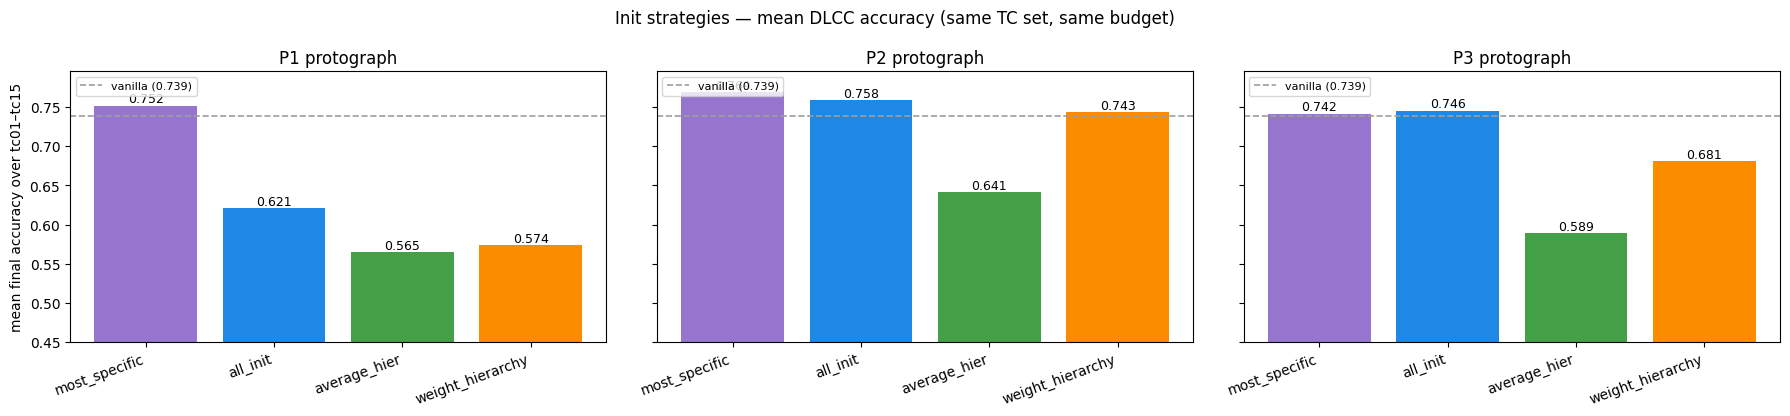

In [7]:
import matplotlib.pyplot as plt

STRAT_COLOR = {
    "most_specific":   "#9575cd",
    "all_init":        "#1e88e5",
    "average_hier":    "#43a047",
    "weight_hierarchy":"#fb8c00",
}

fig, axes = plt.subplots(1, len(PROTOGRAPHS), figsize=(6 * len(PROTOGRAPHS), 4.2), sharey=True)
for ax, proto in zip(axes, PROTOGRAPHS):
    piv = acc_pivot(proto).drop(index="mean")
    means = piv[STRATEGIES].mean()
    vmean = vanilla_final.mean()
    ax.axhline(vmean, color="#9e9e9e", ls="--", lw=1.2, label=f"vanilla ({vmean:.3f})")
    ax.bar(range(len(STRATEGIES)), [means[s] for s in STRATEGIES],
           color=[STRAT_COLOR[s] for s in STRATEGIES])
    for i, s in enumerate(STRATEGIES):
        ax.text(i, means[s] + 0.004, f"{means[s]:.3f}", ha="center", fontsize=9)
    ax.set_xticks(range(len(STRATEGIES)))
    ax.set_xticklabels(STRATEGIES, rotation=20, ha="right")
    ax.set_title(f"{proto.upper()} protograph")
    ax.set_ylim(0.45, max(0.75, means.max() + 0.05))
    ax.legend(loc="upper left", fontsize=8)
axes[0].set_ylabel("mean final accuracy over tc01–tc15")
fig.suptitle("Init strategies — mean DLCC accuracy (same TC set, same budget)")
fig.tight_layout()
fig.savefig(OUT_ROOT / "mean_accuracy_per_strategy.png", dpi=150, bbox_inches="tight")
plt.show()

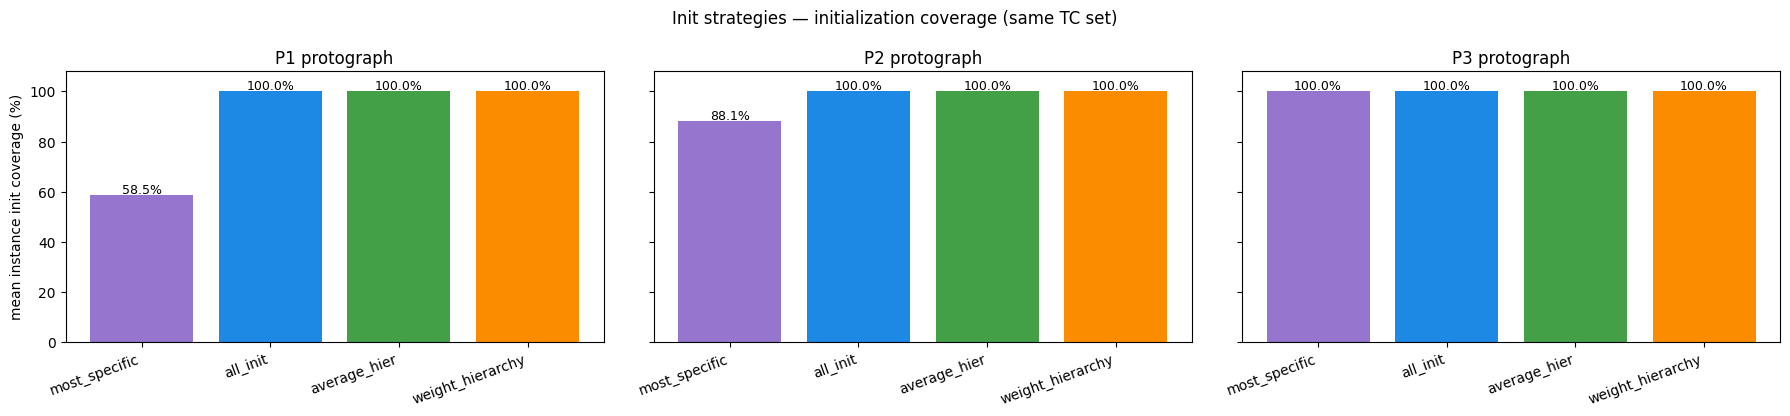

In [8]:
fig, axes = plt.subplots(1, len(PROTOGRAPHS), figsize=(6 * len(PROTOGRAPHS), 4.2), sharey=True)
for ax, proto in zip(axes, PROTOGRAPHS):
    cov = cov_pivot(proto).drop(index="mean")[STRATEGIES].mean()
    ax.bar(range(len(STRATEGIES)), [cov[s] for s in STRATEGIES],
           color=[STRAT_COLOR[s] for s in STRATEGIES])
    for i, s in enumerate(STRATEGIES):
        ax.text(i, cov[s] + 0.8, f"{cov[s]:.1f}%", ha="center", fontsize=9)
    ax.set_xticks(range(len(STRATEGIES)))
    ax.set_xticklabels(STRATEGIES, rotation=20, ha="right")
    ax.set_title(f"{proto.upper()} protograph")
    ax.set_ylim(0, 108)
axes[0].set_ylabel("mean instance init coverage (%)")
fig.suptitle("Init strategies — initialization coverage (same TC set)")
fig.tight_layout()
fig.savefig(OUT_ROOT / "coverage_per_strategy.png", dpi=150, bbox_inches="tight")
plt.show()

## Findings

The cell below prints a short, data-driven summary and writes the LaTeX table
(`init_strategies_table.tex`) consumed by `latex/thesis.tex`.

In [9]:
def fmt_pct(x):
    return "--" if pd.isna(x) else f"{x:.1f}"

def fmt_acc(x):
    return f"{x:.3f}"

lines = []
lines.append(r"\begin{table}[t]")
lines.append(r"\centering")
lines.append(r"\caption{Quantitative comparison of the four class-hierarchy "
             r"initialization strategies on the synthetic DLCC test cases "
             r"\texttt{tc01}--\texttt{tc15}, under one fixed budget "
             r"($\dim=200$, 100 instance walks/entity, depth 3, "
             r"$5+5$ epochs, codes normalized to $8$, finetune LR "
             r"$0.0025$, $\lambda=0.5$, seed 42). "
             r"\emph{Coverage} is the mean fraction of typed instances that "
             r"receive a class-based initialization (rather than a random one); "
             r"\emph{init} and \emph{final} are mean LogReg test accuracy at "
             r"epoch 0 and epoch 5, averaged over all 15 test cases. The "
             r"\texttt{vanilla} row is from-scratch RDF2vec.}")
lines.append(r"\label{tab:init_strategies}")
lines.append(r"\begin{tabular}{llrrr}")
lines.append(r"\toprule")
lines.append(r"Protograph & Strategy & Coverage (\%) & Acc@init & Acc@final \\")
lines.append(r"\midrule")
last_strat = STRATEGIES[-1]
for _, r in summary.iterrows():
    strat = r["strategy"].replace("_", r"\_")
    lines.append(f"{r['proto']} & \\texttt{{{strat}}} & {fmt_pct(r['coverage'])} "
                 f"& {fmt_acc(r['init_acc'])} & {fmt_acc(r['final_acc'])} \\\\")
    # rule after the vanilla anchor and after each protograph block (but not the last)
    is_block_end = r["strategy"] == last_strat and r["proto"] != PROTOGRAPHS[-1].upper()
    if r["strategy"] == "vanilla" or is_block_end:
        lines.append(r"\midrule")
lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")
lines.append(r"\end{table}")
tex = "\n".join(lines) + "\n"
(OUT_ROOT / "init_strategies_table.tex").write_text(tex, encoding="utf-8")
print(tex)

# Data-driven prose summary.
p1 = summary[summary.proto == "P1"].set_index("strategy")
p2 = summary[summary.proto == "P2"].set_index("strategy")
p3 = summary[summary.proto == "P3"].set_index("strategy")
print("Key numbers:")
print(f"  P1 coverage: most_specific {p1.loc['most_specific','coverage']:.1f}% "
      f"-> all_init {p1.loc['all_init','coverage']:.1f}%")
print(f"  P2 coverage: most_specific {p2.loc['most_specific','coverage']:.1f}% "
      f"-> all_init {p2.loc['all_init','coverage']:.1f}%")
print(f"  P3 coverage: most_specific {p3.loc['most_specific','coverage']:.1f}% "
      f"-> all_init {p3.loc['all_init','coverage']:.1f}%")
print(f"  P2 final acc: most_specific {p2.loc['most_specific','final_acc']:.3f}, "
      f"best strategy {p2['final_acc'].idxmax()} {p2['final_acc'].max():.3f}, "
      f"vanilla {summary[summary.strategy=='vanilla']['final_acc'].iloc[0]:.3f}")
print(f"  P3 final acc: most_specific {p3.loc['most_specific','final_acc']:.3f}, "
      f"best strategy {p3['final_acc'].idxmax()} {p3['final_acc'].max():.3f}")

\begin{table}[t]
\centering
\caption{Quantitative comparison of the four class-hierarchy initialization strategies on the synthetic DLCC test cases \texttt{tc01}--\texttt{tc15}, under one fixed budget ($\dim=200$, 100 instance walks/entity, depth 3, $5+5$ epochs, codes normalized to $8$, finetune LR $0.0025$, $\lambda=0.5$, seed 42). \emph{Coverage} is the mean fraction of typed instances that receive a class-based initialization (rather than a random one); \emph{init} and \emph{final} are mean LogReg test accuracy at epoch 0 and epoch 5, averaged over all 15 test cases. The \texttt{vanilla} row is from-scratch RDF2vec.}
\label{tab:init_strategies}
\begin{tabular}{llrrr}
\toprule
Protograph & Strategy & Coverage (\%) & Acc@init & Acc@final \\
\midrule
- & \texttt{vanilla} & -- & 0.488 & 0.739 \\
\midrule
P1 & \texttt{most\_specific} & 58.5 & 0.573 & 0.752 \\
P1 & \texttt{all\_init} & 100.0 & 0.576 & 0.621 \\
P1 & \texttt{average\_hier} & 100.0 & 0.565 & 0.565 \\
P1 & \texttt{weight\_hi